# Exploratory Data Analysis — FPA-FOD 6th Edition

Source: Fire Program Analysis Fire-Occurrence Database (FPA-FOD), 6th Edition (Short 2022) — ~2.3M U.S. wildfires, 1992–2020.

## Load & inspect data

Load the full `Fires` table into a dataframe and confirm its shape and dtypes.
(Imports are kept near first use, so each section stands on its own.)

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd

DB_PATH = Path("..") / "data" / "FPA_FOD_20221014.sqlite"

In [2]:
# Load the full Fires table. Exclude the spatialite `Shape` geometry blob
# (not usable by pandas; LATITUDE/LONGITUDE already carry point location).
with sqlite3.connect(DB_PATH) as conn:
    cols = pd.read_sql_query("PRAGMA table_info(Fires);", conn)["name"].tolist()
    load_cols = [c for c in cols if c != "Shape"]
    df = pd.read_sql_query(f"SELECT {', '.join(load_cols)} FROM Fires", conn)

print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

2,303,566 rows x 38 columns


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,CONT_TIME,FIRE_SIZE,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME
0,1,1,FS-1418826,FED,FS-FIRESTAT,FS,USCAPNF,Plumas National Forest,0511,Plumas National Forest,...,1730,0.10,A,40.036944,-121.005833,USFS,CA,63,06063,Plumas County
1,2,2,FS-1418827,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,1530,0.25,A,38.933056,-120.404444,USFS,CA,61,06061,Placer County
2,3,3,FS-1418835,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,2024,0.10,A,38.984167,-120.735556,STATE OR PRIVATE,CA,17,06017,El Dorado County
3,4,4,FS-1418845,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,1400,0.10,A,38.559167,-119.913333,USFS,CA,3,06003,Alpine County
4,5,5,FS-1418847,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,1200,0.10,A,38.559167,-119.933056,USFS,CA,3,06003,Alpine County


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2303566 entries, 0 to 2303565
Data columns (total 38 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   OBJECTID                       int64  
 1   FOD_ID                         int64  
 2   FPA_ID                         str    
 3   SOURCE_SYSTEM_TYPE             str    
 4   SOURCE_SYSTEM                  str    
 5   NWCG_REPORTING_AGENCY          str    
 6   NWCG_REPORTING_UNIT_ID         str    
 7   NWCG_REPORTING_UNIT_NAME       str    
 8   SOURCE_REPORTING_UNIT          str    
 9   SOURCE_REPORTING_UNIT_NAME     str    
 10  LOCAL_FIRE_REPORT_ID           str    
 11  LOCAL_INCIDENT_ID              str    
 12  FIRE_CODE                      str    
 13  FIRE_NAME                      str    
 14  ICS_209_PLUS_INCIDENT_JOIN_ID  str    
 15  ICS_209_PLUS_COMPLEX_JOIN_ID   str    
 16  MTBS_ID                        str    
 17  MTBS_FIRE_NAME                 str    
 18  COMPLEX_NAME 

## Describing the dataset

A descriptive baseline for the record itself: how big it is, what span and geography it
covers, how complete the analysis variables are, and the shape of `FIRE_SIZE` — the
burned-area measure the research question weights everything by. These are the numbers
the methods section quotes when it says what FPA-FOD is.

### Scale, span, and variable completeness

Dimensions and coverage first, then a completeness table for the handful of columns the
analysis uses — spatial keys (`STATE`, `LATITUDE`/`LONGITUDE`), the cause label
(`NWCG_GENERAL_CAUSE`), the temporal spine (`FIRE_YEAR`, `DISCOVERY_DOY`), and the
burned-area measure (`FIRE_SIZE`). Completeness is reported as the share of rows that
carry a usable (non-null) value, so the report can state which fields are essentially
universal and which are not. Cause is technically never *null* — its incompleteness lives
in a "Missing/undetermined" **category** rather than in null values — so its category
share is reported alongside the null rates.

In [4]:
# Scale and span.
print(f"Rows (fires):        {len(df):,}")
print(f"Columns:             {df.shape[1]}")
print(f"Fire-year span:      {df['FIRE_YEAR'].min()}–{df['FIRE_YEAR'].max()} "
      f"({df['FIRE_YEAR'].nunique()} years)")
print(f"States/territories:  {df['STATE'].nunique()}")
print(f"Total burned area:   {df['FIRE_SIZE'].sum()/1e6:,.1f} million acres")

# Completeness of the columns the analysis uses. Cause is never null (its gap is the
# "Missing/undetermined" category, not a null), so report that category share instead.
key_cols = ["FIRE_YEAR", "DISCOVERY_DOY", "FIRE_SIZE",
            "STATE", "LATITUDE", "LONGITUDE", "NWCG_GENERAL_CAUSE"]
completeness = (
    df[key_cols].notna().mean()
    .mul(100).round(2)
    .rename("non_null_%")
    .to_frame()
)
completeness.loc["NWCG_GENERAL_CAUSE", "note"] = (
    f"{(df['NWCG_GENERAL_CAUSE'] == 'Missing data/not specified/undetermined').mean()*100:.1f}% "
    "in Missing/undetermined category"
)
completeness

Rows (fires):        2,303,566
Columns:             38
Fire-year span:      1992–2020 (29 years)
States/territories:  52
Total burned area:   180.0 million acres


,non_null_%,note
FIRE_YEAR,100.0,NaN
DISCOVERY_DOY,100.0,NaN
FIRE_SIZE,100.0,NaN
STATE,100.0,NaN
LATITUDE,100.0,NaN
LONGITUDE,100.0,NaN
NWCG_GENERAL_CAUSE,100.0,26.0% in Missing/undetermined category


### How is burned area distributed across fires?

**Hypothesis.** `FIRE_SIZE` is the variable the project weights by. If burn is concentrated in
a thin tail of large fires, weighting by acres is materially different from counting ignitions.

**Experiment.** Quantile table across the full range, the share of total acres held by the
largest fires, and a histogram on a log size axis (a linear axis collapses every fire into the
first bar).

count   2,303,566
mean    78.2 acres
median  0.80 acres
min     0.000 acres
p50     0.8 acres
p90     15.0 acres
p99     477.0 acres
p99.9   12,730.1 acres
max     662,700.0 acres
top 0.01% of fires (>= 106,439 ac): 26.8% of all burned acres
top  0.1% of fires (>= 12,730 ac): 64.3% of all burned acres
top    1% of fires (>= 477 ac): 89.7% of all burned acres


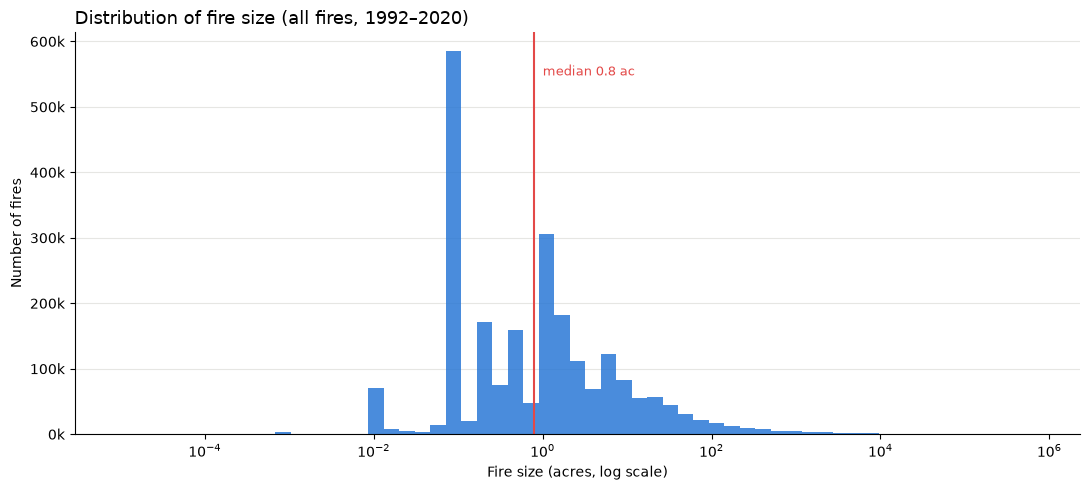

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

size = df["FIRE_SIZE"]

# Quantify the skew: mean >> median, and a long upper tail.
qs = [0.5, 0.9, 0.99, 0.999, 1.0]
print(f"count   {size.size:,}")
print(f"mean    {size.mean():,.1f} acres")
print(f"median  {size.median():,.2f} acres")
print(f"min     {size.min():,.3f} acres")
for q in qs:
    label = "max" if q == 1.0 else f"p{q*100:g}"
    print(f"{label:<7} {size.quantile(q):,.1f} acres")

# Share of total burned area contributed by the largest fires (the tail-drives-acres point).
for top_pct in [0.01, 0.1, 1.0]:
    thr = size.quantile(1 - top_pct / 100)
    share = size[size >= thr].sum() / size.sum() * 100
    print(f"top {top_pct:>4g}% of fires (>= {thr:,.0f} ac): {share:4.1f}% of all burned acres")

# Histogram on a log-size axis (a linear axis would pile every fire in bin 1).
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.logspace(np.log10(size.min()), np.log10(size.max()), 60)
ax.hist(size, bins=bins, color="#2a78d6", alpha=0.85)
ax.axvline(size.median(), color="#e34948", lw=1.5)
ax.annotate(f"median {size.median():.2g} ac", (size.median(), 0.92),
            xycoords=("data", "axes fraction"), xytext=(6, 0),
            textcoords="offset points", color="#e34948", fontsize=9, va="top")
ax.set_xscale("log")
ax.set_title("Distribution of fire size (all fires, 1992–2020)", fontsize=13, loc="left")
ax.set_xlabel("Fire size (acres, log scale)")
ax.set_ylabel("Number of fires")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:g}k"))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Finding.** The distribution spans nine orders of magnitude, from sub-acre starts to a
~663,000-acre maximum, with a mean (~78 acres) far above the median.

Burn is overwhelmingly tail-driven: **most fires are tiny, but a thin tail of very large fires
carries almost all the burned area.** This is why the analysis weights by acres rather than
counting ignitions, and why every downstream metric is reported acre-weighted.

### Coverage: fires per year and where they are

Two coverage views, both record counts rather than burned area. **Left:** fires recorded per
year, showing continuity across 1992–2020 with no missing years. **Right:** the states carrying
the most fires — coverage is national but concentrated in the South and West.

/var/folders/hr/t1_4y5dd3nqgxcj6kn65dgdm0000gn/T/ipykernel_78316/2125384076.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


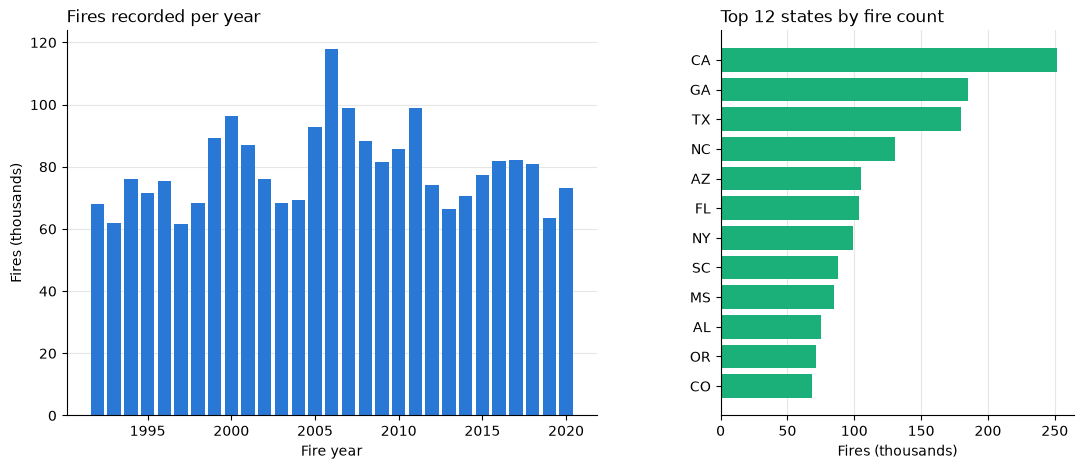

Top 12 states hold 63% of all fires; lower-48 + AK/HI span 52 states/territories.


In [6]:
# Record volume over time and geographic concentration (counts, not acres).
per_year = df.groupby("FIRE_YEAR").size()
top_states = df["STATE"].value_counts().head(12).sort_values()

fig, (axl, axr) = plt.subplots(1, 2, figsize=(13, 5),
                               gridspec_kw=dict(width_ratios=[3, 2], wspace=0.28))

# Left: fires per year — continuity of the record.
axl.bar(per_year.index, per_year.values / 1000, color="#2a78d6", width=0.8)
axl.set_title("Fires recorded per year", fontsize=12, loc="left")
axl.set_xlabel("Fire year")
axl.set_ylabel("Fires (thousands)")

# Right: states carrying the most fires — national but concentrated.
axr.barh(top_states.index, top_states.values / 1000, color="#1baf7a")
axr.set_title("Top 12 states by fire count", fontsize=12, loc="left")
axr.set_xlabel("Fires (thousands)")

for a in (axl, axr):
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(axis="x" if a is axr else "y", color="#e6e6e3", lw=0.8)
    a.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Top 12 states hold {top_states.sum()/len(df):.0%} of all fires; "
      f"lower-48 + AK/HI span {df['STATE'].nunique()} states/territories.")

## Do the causes driving burned area hold steady across 1992–2020?

**Hypothesis.** If cause composition is stable over the record, one historical profile describes
it. If it trends, the profile is time-dependent and recent years carry more weight.

**Experiment.** Aggregate acres burned per cause per year, then take each cause's share of that
year's acres so the trend reads independently of how big the year was. Burned area, not counts,
because `FIRE_SIZE` is heavily right-skewed and the project weights by acres.

In [7]:
# Acres burned per cause per year.
acres_by = (
    df.groupby(["FIRE_YEAR", "NWCG_GENERAL_CAUSE"])["FIRE_SIZE"]
    .sum()
    .unstack(fill_value=0.0)
    .sort_index()
)
# Order causes by total burned area over the whole period.
cause_order = acres_by.sum().sort_values(ascending=False).index.tolist()
acres_by = acres_by[cause_order]

# Each cause's share of that year's total burned area.
share_by = acres_by.div(acres_by.sum(axis=1), axis=0)

acres_by.head()

NWCG_GENERAL_CAUSE,Natural,Missing data/not specified/undetermined,Arson/incendiarism,Equipment and vehicle use,Debris and open burning,Recreation and ceremony,Power generation/transmission/distribution,Railroad operations and maintenance,Smoking,Firearms and explosives use,Fireworks,Misuse of fire by a minor,Other causes
FIRE_YEAR,,,,,,,,,,,,,
1992,1007933.45,455085.019,267422.330,136491.699,155551.772,27638.330,3365.39,38066.640,52718.168,0.1,4092.45,50545.513,1011.67
1993,1113048.05,463868.301,192829.403,123214.260,111554.413,30745.849,34625.66,43177.148,57053.350,5.3,7866.53,13376.679,222.06
1994,2397151.24,666133.345,477384.607,136058.940,185184.520,69928.230,17389.02,41323.470,58843.113,0.0,16243.89,14082.844,35859.13
1995,834573.81,417208.207,293903.820,117872.189,192824.981,70106.653,28553.09,24297.600,51990.230,19.0,3806.94,12739.358,1657.28
1996,3324920.17,916104.035,515666.440,526533.820,297352.020,159742.690,88918.31,65060.900,43474.020,7.6,48711.65,17927.754,413.85


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Keep the top burned-area drivers; fold the tail into "Other" so 13 lines stay readable.
N_TOP = 6
top_causes = cause_order[:N_TOP]
tail = cause_order[N_TOP:]

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
colors = dict(zip(top_causes, PALETTE))
colors["Other"] = "#8a8a86"  # neutral gray for the folded tail

def collapse(frame):
    out = frame[top_causes].copy()
    out["Other"] = frame[tail].sum(axis=1)
    return out

def label_lines(ax, frame):
    """Direct-label each line at its right end."""
    x = frame.index.max()
    for col in frame.columns:
        y = frame[col].iloc[-1]
        ax.annotate(col, (x, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8, color=colors[col])

print("Top drivers:", top_causes)
print("Folded into 'Other':", tail)

Top drivers: ['Natural', 'Missing data/not specified/undetermined', 'Arson/incendiarism', 'Equipment and vehicle use', 'Debris and open burning', 'Recreation and ceremony']
Folded into 'Other': ['Power generation/transmission/distribution', 'Railroad operations and maintenance', 'Smoking', 'Firearms and explosives use', 'Fireworks', 'Misuse of fire by a minor', 'Other causes']


### Burned area by cause

Absolute acres burned per cause per year, with smaller causes folded into "Other".

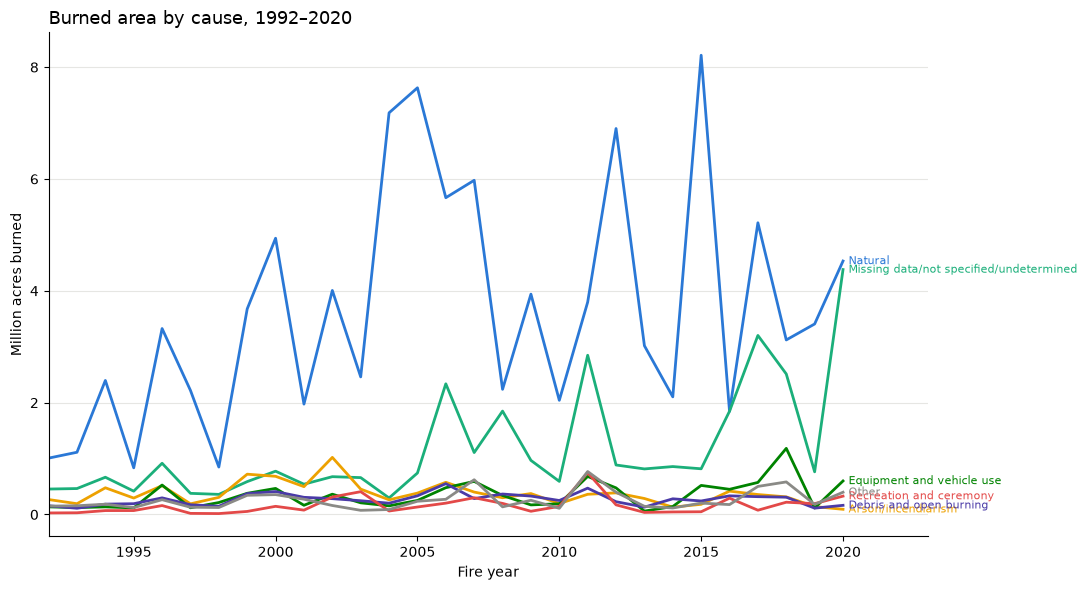

In [9]:
# Absolute burned area per cause per year.
acres_top = collapse(acres_by)

fig, ax = plt.subplots(figsize=(11, 6))
for col in acres_top.columns:
    ax.plot(acres_top.index, acres_top[col] / 1e6, color=colors[col], lw=2)
label_lines(ax, acres_top / 1e6)
ax.set_title("Burned area by cause, 1992–2020", fontsize=13, loc="left")
ax.set_ylabel("Million acres burned")
ax.set_xlabel("Fire year")
ax.set_xlim(acres_top.index.min(), acres_top.index.max() + 3)  # room for labels
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Cause share of burned area

The same causes as a share of each year's total burned area, so the trend reads independently
of how big the year was overall.

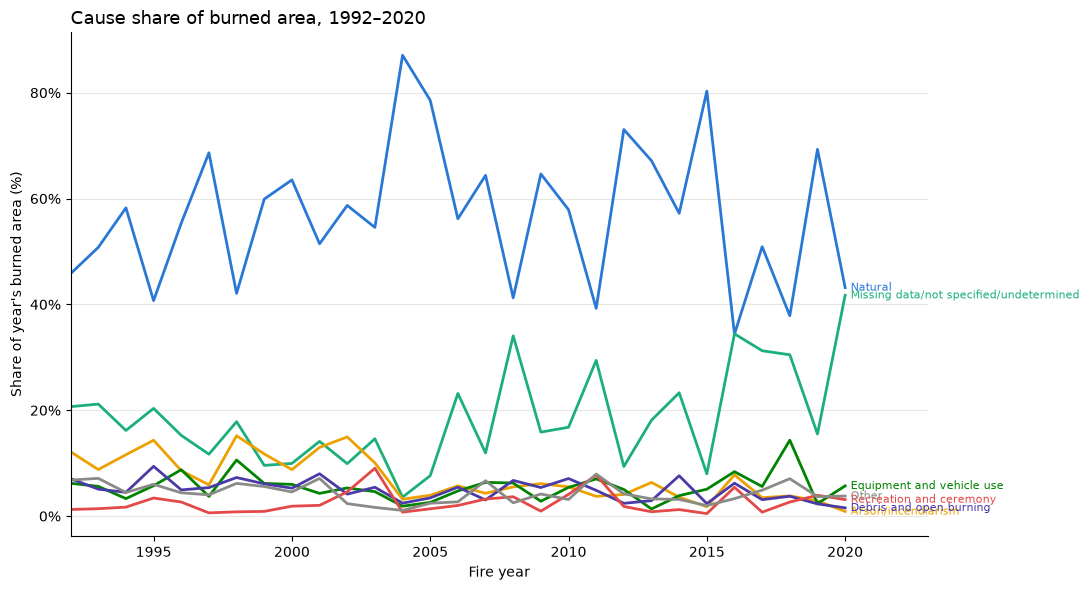

In [10]:
# Each cause's share of that year's burned area.
share_top = collapse(share_by)

fig, ax = plt.subplots(figsize=(11, 6))
for col in share_top.columns:
    ax.plot(share_top.index, share_top[col] * 100, color=colors[col], lw=2)
label_lines(ax, share_top * 100)
ax.set_title("Cause share of burned area, 1992–2020", fontsize=13, loc="left")
ax.set_ylabel("Share of year's burned area (%)")
ax.set_xlabel("Fire year")
ax.set_xlim(share_top.index.min(), share_top.index.max() + 3)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Natural-cause deep-dive

Natural is the dominant burned-area driver, so it gets a closer look: how its fire-size
distribution moves year to year, and whether the large-fire tail is growing.

### How does the Natural fire-size distribution move across 1992–2020?

**Hypothesis.** If the whole size distribution shifts — median drifting, tails stretching —
that is a different phenomenon from a few extra large fires in some years.

**Experiment.** A per-year violin plot on a log axis: each violin is that year's full fire-size
distribution with the median marked. Fire size spans ~9 orders of magnitude, so the density is
estimated on `log10(FIRE_SIZE)` and the axis relabelled in acres.

saved -> ../img/natural_size_violin.png


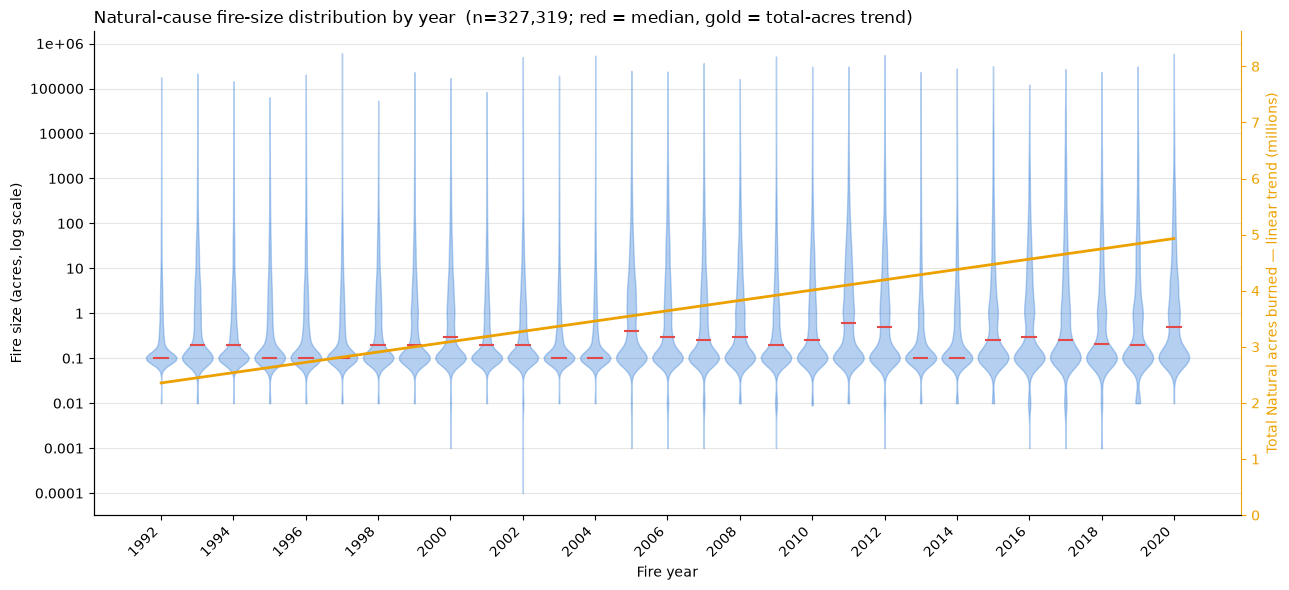

Total Natural acres, linear trend: +0.092M acres/year (mean 3.6M/yr, range 0.8–8.2M)


In [11]:
import numpy as np

natural = df.loc[df["NWCG_GENERAL_CAUSE"] == "Natural", ["FIRE_YEAR", "FIRE_SIZE"]].copy()

# Estimate the density on log10(size) so the KDE isn't crushed by the skew.
# No zeros/negatives in the Natural subset, so log10 is defined for every row.
natural["log10_size"] = np.log10(natural["FIRE_SIZE"])

years = sorted(natural["FIRE_YEAR"].unique())
by_year = [natural.loc[natural["FIRE_YEAR"] == y, "log10_size"].values for y in years]

# Total Natural acres per year.
acres_per_year = natural.groupby("FIRE_YEAR")["FIRE_SIZE"].sum().reindex(years)

fig, ax = plt.subplots(figsize=(13, 6))
vp = ax.violinplot(by_year, positions=years, widths=0.85,
                   showmedians=True, showextrema=False)
for body in vp["bodies"]:
    body.set_facecolor("#2a78d6")
    body.set_edgecolor("#2a78d6")
    body.set_alpha(0.35)
vp["cmedians"].set_color("#e34948")
vp["cmedians"].set_linewidth(1.5)

ax.set_title(f"Natural-cause fire-size distribution by year  (n={len(natural):,}; "
             "red = median, gold = total-acres trend)", fontsize=12, loc="left")
ax.set_xlabel("Fire year")
ax.set_ylabel("Fire size (acres, log scale)")

# Y is in log10 units; relabel ticks back to real acres.
lo, hi = np.floor(natural["log10_size"].min()), np.ceil(natural["log10_size"].max())
yt = np.arange(lo, hi + 1)
ax.set_yticks(yt)
ax.set_yticklabels([f"{10**t:g}" for t in yt])

# Second axis: linear trend in total acres per year. A different quantity from the per-fire
# sizes in the violins, so it gets its own scale and color. Only the fitted direction is drawn;
# the yearly totals are tail-driven and spiky.
acres_m = acres_per_year.values / 1e6
slope, intercept = np.polyfit(years, acres_m, 1)

ax2 = ax.twinx()
ax2.plot(years, np.asarray(years) * slope + intercept, color="#eda100", lw=2, zorder=3)
ax2.set_ylabel("Total Natural acres burned — linear trend (millions)", color="#eda100")
ax2.tick_params(axis="y", colors="#eda100")
ax2.set_ylim(0, acres_m.max() * 1.05)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color("#eda100")
ax2.grid(False)

ax.set_xticks(years[::2])
ax.set_xticklabels(years[::2], rotation=45, ha="right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()

# Export for the write-ups. Overwrites the existing file.
IMG = Path("..") / "img" / "natural_size_violin.png"
fig.savefig(IMG, dpi=200, bbox_inches="tight", facecolor="white")
print(f"saved -> {IMG}")

plt.show()

print(f"Total Natural acres, linear trend: {slope:+.3f}M acres/year "
      f"(mean {acres_m.mean():.1f}M/yr, range {acres_m.min():.1f}–{acres_m.max():.1f}M)")

### Is the upper tail actually growing?

**Hypothesis.** The violins suggest mass above the median thickens over time. If the share of
Natural fires reaching a large size rises, the upper body is genuinely fattening.

**Experiment.** Per year, the share of Natural fires at or above 10, 100 and 1,000 acres — with
the per-year fire **count** plotted underneath, because a share is a ratio and a shrinking
denominator inflates it without any change in fire behavior.

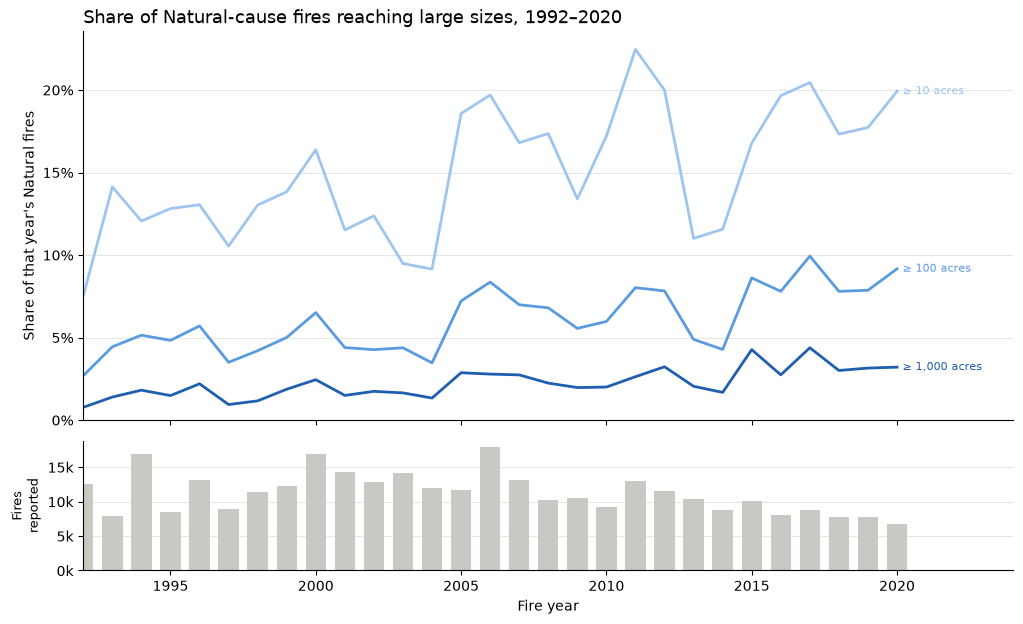

In [12]:
# Per-year share of Natural fires at/above each size threshold, plus the yearly count.
thresholds = [10, 100, 1000]
grp = natural.groupby("FIRE_YEAR")["FIRE_SIZE"]
n_by_year = grp.size()
share = pd.DataFrame(
    {t: grp.apply(lambda s, t=t: (s >= t).mean()) * 100 for t in thresholds}
)

# Sequential encoding: thresholds are ordered magnitudes, so one hue light->dark.
ramp = {10: "#9ec5f0", 100: "#5a9be0", 1000: "#1f5fb0"}

fig, (ax, axn) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08),
)

for t in thresholds:
    ax.plot(share.index, share[t], color=ramp[t], lw=2)
    ax.annotate(f"≥ {t:,} acres", (share.index.max(), share[t].iloc[-1]),
                xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8, color=ramp[t])
ax.set_title("Share of Natural-cause fires reaching large sizes, 1992–2020",
             fontsize=13, loc="left")
ax.set_ylabel("Share of that year's Natural fires")
ax.set_xlim(share.index.min(), share.index.max() + 4)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(bottom=0)

# Lower panel: yearly count.
axn.bar(n_by_year.index, n_by_year.values, color="#c9c8c3", width=0.7)
axn.set_ylabel("Fires\nreported", fontsize=9)
axn.set_xlabel("Fire year")
axn.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:g}k"))

for a in (ax, axn):
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(axis="y", color="#e6e6e3", lw=0.8)
    a.set_axisbelow(True)
plt.show()

**Finding.** Across all three thresholds the share of Natural fires reaching a large size
**rises into the late 2010s** — the ≥1,000-acre share roughly doubles.

But the count of reported Natural fires **falls** over the same period, from ~13–17k/year early
to ~7–8k/year by 2018–2020. A share is a ratio, so a shrinking denominator inflates it even if
the number of large fires is unchanged. Two explanations remain open:

- **Real behavior change** — genuinely more large Natural fires.
- **Reporting artifact** — fewer *small* Natural fires entering the record, so the survivors
  skew large.

The Missing-cause share climbs after ~2010 in the same window that Natural counts fall (measured
in [`03_missingness.ipynb`](03_missingness.ipynb)). If fires once labelled *Natural* are
increasingly recorded as *Missing*, and if the unattributed ones are disproportionately small,
the denominator loss would be both Natural-specific and size-correlated — exactly what would
manufacture an apparent tail trend. That is a hypothesis linking two observations, not something
these plots establish.

**The upward tail signal is directionally consistent with a real shift, but its magnitude is not
trustworthy while the denominator is confounded.**

## Which human causes drive human-caused burned area, and is the mix steady?

**Hypothesis.** Human causes are the preventable ones, so their internal composition is what a
prevention programme acts on. If that mix shifts across the record, the target shifts with it.

**Experiment.** Drop `Natural` and `Missing data/not specified/undetermined`, then **renormalize
within human-caused acres**: each share is that cause's fraction of burned area attributed to
*human* ignitions, not of all fire. Same conventions as above — top drivers by burned area, tail
folded to "Other", direct labels.

Over 1992–2020 human causes account for ~23% of all acres burned (Natural ~59%, Missing ~19%).
This section is about the internal structure of that 23%.

In [13]:
# Everything except Natural and the Missing/undetermined bucket.
NON_HUMAN = ["Natural", "Missing data/not specified/undetermined"]
human_cols = [c for c in acres_by.columns if c not in NON_HUMAN]

# Acres per human cause per year, then each cause's share *within human-caused acres*.
h_acres_by = acres_by[human_cols]
h_share_by = h_acres_by.div(h_acres_by.sum(axis=1), axis=0)

# Own ordering for the human subset.
h_cause_order = h_acres_by.sum().sort_values(ascending=False).index.tolist()
H_N_TOP = 5
h_top = h_cause_order[:H_N_TOP]
h_tail = h_cause_order[H_N_TOP:]

# Reuse the same base hues in fixed rank order: identity, not rank.
h_colors = dict(zip(h_top, PALETTE))
h_colors["Other"] = "#8a8a86"

def h_collapse(frame):
    out = frame[h_top].copy()
    out["Other"] = frame[h_tail].sum(axis=1)
    return out

def h_label_lines(ax, frame):
    x = frame.index.max()
    for col in frame.columns:
        y = frame[col].iloc[-1]
        ax.annotate(col, (x, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8, color=h_colors[col])

print("Human top drivers:", h_top)
print("Folded into 'Other':", h_tail)
print("Human share of all acres: "
      f"{acres_by[human_cols].sum().sum() / acres_by.sum().sum():.1%}")

Human top drivers: ['Arson/incendiarism', 'Equipment and vehicle use', 'Debris and open burning', 'Recreation and ceremony', 'Power generation/transmission/distribution']
Folded into 'Other': ['Railroad operations and maintenance', 'Smoking', 'Firearms and explosives use', 'Fireworks', 'Misuse of fire by a minor', 'Other causes']
Human share of all acres: 22.6%


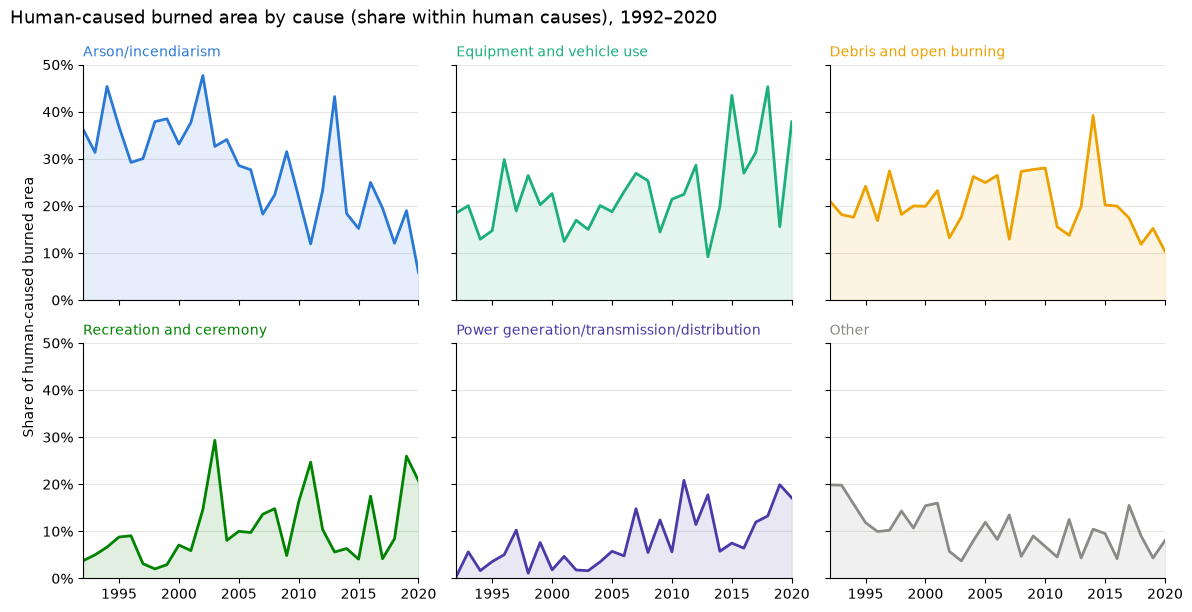

In [14]:
# Small multiples rather than a stack: a stack forces every band but the bottom to ride a
# wobbling baseline. Each cause gets its own panel on a shared y-axis, so trends sit on a flat
# baseline and panels compare directly.
h_share_top = h_collapse(h_share_by)
panel_order = h_top + ["Other"]
years = h_share_top.index
ymax = np.ceil(h_share_top.max().max() * 100 / 5) * 5  # shared y-limit, rounded to 5%

ncol = 3
nrow = int(np.ceil(len(panel_order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3.1 * nrow),
                         sharex=True, sharey=True)
axes = axes.ravel()

for ax, c in zip(axes, panel_order):
    y = h_share_top[c].values * 100
    ax.plot(years, y, color=h_colors[c], lw=2)
    ax.fill_between(years, y, color=h_colors[c], alpha=0.12)
    ax.set_title(c, fontsize=10, loc="left", color=h_colors[c])
    ax.set_ylim(0, ymax)
    ax.set_xlim(years.min(), years.max())
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color="#e6e6e3", lw=0.8)
    ax.set_axisbelow(True)

for ax in axes[len(panel_order):]:  # hide any empty trailing panel
    ax.set_visible(False)

fig.suptitle("Human-caused burned area by cause (share within human causes), 1992–2020",
             fontsize=13, x=0.01, ha="left")
fig.supylabel("Share of human-caused burned area", fontsize=10)
fig.tight_layout()
plt.show()

**Finding.** The composition of human-caused burned area shifts across 1992–2020:

- **Arson/incendiarism** trends **down**, from the 30–40% range early to the teens late.
- **Debris and open burning** trends **slightly down**.
- **Equipment and vehicle use** trends **clearly up**, from the high teens toward the high
  30s/40s.
- **Power generation/transmission/distribution** drifts **up** in the back half.

The mix is tilting from *intentional* (arson) and *traditional-rural* (debris burning) ignitions
toward *accidental and infrastructure* ignitions.

**What these panels cannot settle.** The shares are computed within human-caused acres, so they
are coupled: a down-trend in one cause can be partly an artifact of another rising. Separating
"arson actually falling" from "equipment rising and pushing arson's share down" needs the
absolute-acres view. Year-to-year movement is also spiky because burned area is tail-driven, so
the trend is the signal, not individual peaks.

Whether more people and development in fire-prone land drives the equipment/power rise is a
claim about **exposure**, which shares do not measure. Testing it would need a population,
land-use or WUI layer joined by ecoregion — deferred until the base data has been exhausted.

## How much burned area has no attributed cause, and is that share stable?

**Hypothesis.** `Missing/undetermined` is a large slice of the record. If its weight is constant,
it is background noise; if it moves, it constrains what every cause claim above can say.

**Experiment.** Track the Missing-cause **share of burned area** per year (the project's
weighting), with its **share of fire count** alongside.

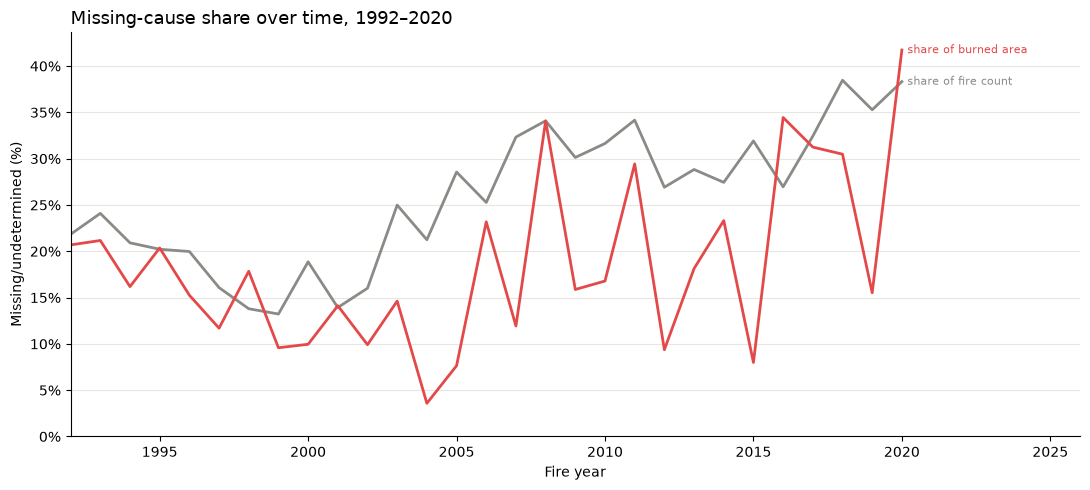

Missing share of burned area: 19% (1992–96) -> 31% (2016–20)
Missing share of fire count:  21% (1992–96) -> 34% (2016–20)


In [15]:
MISSING = "Missing data/not specified/undetermined"

# Missing-cause share of burned area per year (reuses share_by from the cause-composition
# section), alongside its share of fire count.
miss_acre_share = share_by[MISSING] * 100
miss_count_share = (
    df.assign(is_missing=df["NWCG_GENERAL_CAUSE"] == MISSING)
    .groupby("FIRE_YEAR")["is_missing"].mean() * 100
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(miss_count_share.index, miss_count_share.values, color="#8a8a86", lw=2)
ax.plot(miss_acre_share.index, miss_acre_share.values, color="#e34948", lw=2)
for series, color, name in [
    (miss_count_share, "#8a8a86", "share of fire count"),
    (miss_acre_share, "#e34948", "share of burned area"),
]:
    ax.annotate(name, (series.index.max(), series.iloc[-1]), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8, color=color)
ax.set_title("Missing-cause share over time, 1992–2020", fontsize=13, loc="left")
ax.set_ylabel("Missing/undetermined (%)")
ax.set_xlabel("Fire year")
ax.set_xlim(miss_acre_share.index.min(), miss_acre_share.index.max() + 6)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Missing share of burned area: {miss_acre_share.iloc[:5].mean():.0f}% (1992–96) "
      f"-> {miss_acre_share.iloc[-5:].mean():.0f}% (2016–20)")
print(f"Missing share of fire count:  {miss_count_share.iloc[:5].mean():.0f}% (1992–96) "
      f"-> {miss_count_share.iloc[-5:].mean():.0f}% (2016–20)")

**Finding.** Two things stand out, and both bound every cause claim in this project.

**The share is large and rising.** Missing/undetermined runs well into double digits throughout
and climbs in the back half of the record, so cause attribution is *least* complete in exactly
the recent years the predictive product depends on.

**Burned-area share sits below count share.** The Missing slice is consistently a smaller
fraction of *acres* than of *fires*, so missing-cause fires skew small. That is favourable for an
acre-weighted product, but it is an aggregate that hides structure.

The operating conclusion carried forward: report cause as **shares within attributed fires**,
treat recent and regional magnitudes as directional, and lean on the fact that the largest fires
— which drive the acre totals — are the best-attributed part of the record.

Where missingness concentrates by agency, state and ecoregion, whether the post-2010 rise is real,
and how the size-dependence behaves across the full range are decomposed in
[`03_missingness.ipynb`](03_missingness.ipynb).